<a href="https://colab.research.google.com/github/dinda-dwi-lestari/Pengantar-Proses-Stokastik/blob/main/Simulasi_Antrian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


SIMULASI SPKLU M/M/1

Pelanggan 1 datang pada 0.18 jam (11.04 menit)
Kebutuhan energi mobil : 23.93 kWh
Pelanggan dilayani Server 1
Lama charging : 0.48 jam (28.72 menit)
Pelanggan 1 selesai pada 0.66 jam (39.76 menit)

Pelanggan 2 datang pada 1.03 jam (61.53 menit)
Kebutuhan energi mobil : 37.40 kWh
Pelanggan dilayani Server 1
Lama charging : 0.75 jam (44.88 menit)

Pelanggan 3 datang pada 1.22 jam (73.02 menit)
Kebutuhan energi mobil : 47.66 kWh
Pelanggan 3 masuk antrean
Pelanggan 2 selesai pada 1.77 jam (106.41 menit)
Pelanggan 3 menunggu 0.56 jam 

Pelanggan 4 datang pada 2.25 jam (135.15 menit)
Kebutuhan energi mobil : 59.47 kWh
Pelanggan 4 masuk antrean
Pelanggan 3 selesai pada 2.73 jam (163.60 menit)
Pelanggan 4 menunggu 0.47 jam 
Pelanggan 4 selesai pada 3.92 jam (234.97 menit)

Pelanggan 5 datang pada 4.67 jam (280.05 menit)
Kebutuhan energi mobil : 79.13 kWh
Pelanggan dilayani Server 1
Lama charging : 1.58 jam (94.96 menit)

Pelanggan 6 datang pada 5.73 jam (343.96 menit)
Ke

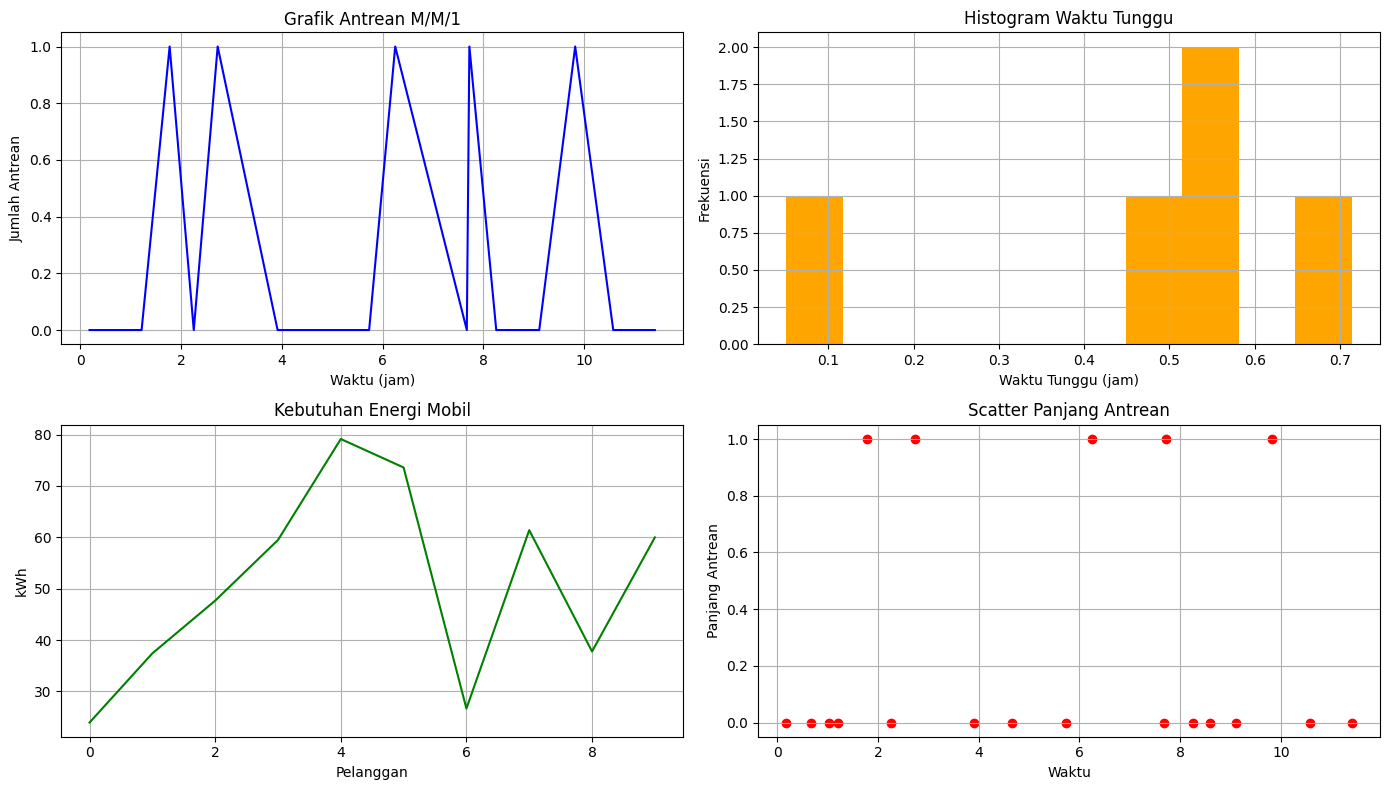

In [ ]:
# =========================================================
# SIMULASI ANTRIAN M/M/1 SPKLU
# =========================================================

import random
from collections import deque
import matplotlib.pyplot as plt

# =========================================================
# CLASS EVENT
# =========================================================

class Event:
    def __init__(self, waktu, tipe, pelanggan):

        self.waktu = waktu
        self.tipe = tipe
        self.pelanggan = pelanggan

# =========================================================
# CLASS SISTEM ANTRIAN
# =========================================================

class QueueingSystem:
    def __init__(
        self,
        num_servers,
        arrival_rate,
        charger_power,
        working_hours):

        # jumlah server
        self.num_servers = num_servers

        # lambda kedatangan
        self.arrival_rate = arrival_rate

        # daya charger (kW)
        self.charger_power = charger_power

        # jam kerja
        self.working_hours = working_hours

        # antrean
        self.queue = deque()

        # daftar event
        self.event_list = []

        # status server
        self.servers_busy = [False] * num_servers

        # waktu sekarang
        self.current_time = 0

        # statistik
        self.total_customers = 0
        self.customers_served = 0

        self.total_wait_time = 0
        self.total_service_time = 0

        # data visualisasi
        self.queue_history = []
        self.time_history = []
        self.waiting_history = []

        # data kWh kendaraan
        self.kwh_history = []

    # =====================================================
    # GENERATE WAKTU KEDATANGAN
    # =====================================================

    def generate_arrival(self):
        return random.expovariate(self.arrival_rate)

    # =====================================================
    # GENERATE KWH MOBIL
    # =====================================================

    def generate_kwh(self):
        # kendaraan membutuhkan energi antara 20 - 80 kWh
        return random.uniform(20, 80)

    # =====================================================
    # HITUNG WAKTU PELAYANAN
    # =====================================================

    def generate_service_time(self, kwh):
        # waktu charging = energi / daya charger
        return kwh / self.charger_power

    # =====================================================
    # TAMBAH EVENT
    # =====================================================

    def add_event(self, event):
        self.event_list.append(event)
        self.event_list.sort(key=lambda x: x.waktu)

    # =====================================================
    # RUN SIMULATION
    # =====================================================

    def run_simulation(self):
        self.total_customers = 1

        # pelanggan pertama
        first_arrival = self.generate_arrival()
        self.add_event(
            Event(first_arrival, "arrival", 1))

        # simulasi berjalan selama jam kerja
        while (
            len(self.event_list) > 0 and
            self.current_time < self.working_hours):
            current_event = self.event_list.pop(0)
            self.current_time = current_event.waktu

            # hentikan jika melebihi jam kerja
            if self.current_time > self.working_hours:
                break

            # simpan data grafik
            self.queue_history.append(len(self.queue))
            self.time_history.append(self.current_time )

            # proses event
            if current_event.tipe == "arrival":
                self.handle_arrival(current_event)
            elif current_event.tipe == "departure":
                self.handle_departure(current_event )

        print("\n===================================")
        print("SIMULASI BERAKHIR")
        print("===================================")
        print(f"Waktu operasional selesai : "f"{self.current_time:.2f} jam" )
        print(f"Total pelanggan dilayani : "f"{self.customers_served}")

    # =====================================================
    # HANDLE ARRIVAL
    # =====================================================

    def handle_arrival(
        self,
        event):
        menit_datang = event.waktu * 60
        print(f"\nPelanggan {event.pelanggan} datang "
            f"pada {event.waktu:.2f} jam "
            f"({menit_datang:.2f} menit)")

        # generate kebutuhan charging
        kwh = self.generate_kwh()
        self.kwh_history.append(kwh)
        print(f"Kebutuhan energi mobil : "f"{kwh:.2f} kWh")

        # pelanggan berikutnya
        self.total_customers += 1
        next_arrival = (self.current_time + self.generate_arrival())

        # hanya tambahkan jika masih dalam jam kerja
        if next_arrival <= self.working_hours:
            self.add_event(
                Event(  next_arrival,
                    "arrival",
                    self.total_customers))

        # cek server kosong
        free_server = -1
        for i in range(self.num_servers):
            if not self.servers_busy[i]:
                free_server = i
                break

        # jika server tersedia
        if free_server != -1:
            self.servers_busy[free_server] = True

            # hitung waktu charging
            service_time = self.generate_service_time(kwh)
            self.total_service_time += service_time
            selesai = (self.current_time + service_time)
            self.add_event(
                Event( selesai,
                    "departure",
                    event.pelanggan))
            print(f"Pelanggan dilayani "f"Server {free_server+1}")
            print(f"Lama charging : "f"{service_time:.2f} jam "
            f"({service_time*60:.2f} menit)")
        else:
            # masuk antrean
            self.queue.append({
                "id": event.pelanggan,
                "arrival_time": self.current_time,
                "kwh": kwh})
            print(f"Pelanggan {event.pelanggan} "f"masuk antrean")

    # =====================================================
    # HANDLE DEPARTURE
    # =====================================================

    def handle_departure(self, event):
        menit_selesai = event.waktu * 60
        print(f"Pelanggan {event.pelanggan} selesai "
            f"pada {event.waktu:.2f} jam "
            f"({menit_selesai:.2f} menit)" )
        self.customers_served += 1

        # jika antrean kosong
        if len(self.queue) == 0:
            for i in range(self.num_servers):
                self.servers_busy[i] = False
        else:
            next_customer = self.queue.popleft()
            waiting_time = (self.current_time - next_customer["arrival_time"])
            self.total_wait_time += waiting_time
            self.waiting_history.append(waiting_time)
            print(f"Pelanggan "
                f"{next_customer['id']} "
                f"menunggu "
                f"{waiting_time:.2f} jam ")

            # waktu charging berdasarkan kWh
            service_time = self.generate_service_time(next_customer["kwh"])
            self.total_service_time += service_time
            selesai = (self.current_time + service_time)
            self.add_event(
                Event(
                    selesai,
                    "departure",
                    next_customer["id"]))

    # =====================================================
    # HASIL SIMULASI
    # =====================================================

    def get_results(self):
        # rata-rata waktu tunggu
        average_wait = (self.total_wait_time / self.customers_served)

        # rata-rata charging
        average_service = (self.total_service_time /  self.customers_served)

        # rata-rata kWh
        average_kwh = (sum(self.kwh_history) / len(self.kwh_history))

        # utilisasi server
        rho = (self.arrival_rate * average_service) / self.num_servers

        return {
            "Jumlah Server":self.num_servers,
            "Lambda":self.arrival_rate,
            "Daya Charger (kW)":self.charger_power,
            "Jam Kerja":self.working_hours,
            "Total Pelanggan":self.customers_served,
            "Rata-rata kWh Mobil":average_kwh,
            "Rata-rata Waktu Charging (jam)":average_service,
            "Rata-rata Waktu Charging (menit)":average_service * 60,
            "Rata-rata Waktu Tunggu (jam)": average_wait,
            "Rata-rata Waktu Tunggu (menit)": average_wait * 60,
            "Utilisasi Server": rho}

    # =====================================================
    # VISUALISASI
    # =====================================================

    def visualisasi(self):
        plt.figure(figsize=(14,8))

        # ---------------------------------------------
        # Grafik antrean
        # ---------------------------------------------

        plt.subplot(2,2,1)
        plt.plot(
            self.time_history,
            self.queue_history,
            color='blue')
        plt.title(f"Grafik Antrean M/M/1")
        plt.xlabel("Waktu (jam)")
        plt.ylabel("Jumlah Antrean")
        plt.grid(True)

        # ---------------------------------------------
        # Histogram waktu tunggu
        # ---------------------------------------------

        plt.subplot(2,2,2)
        plt.hist(
            self.waiting_history,
            bins=10,
            color='orange' )
        plt.title("Histogram Waktu Tunggu")
        plt.xlabel("Waktu Tunggu (jam)")
        plt.ylabel("Frekuensi")
        plt.grid(True)

        # ---------------------------------------------
        # Grafik kebutuhan energi
        # ---------------------------------------------

        plt.subplot(2,2,3)
        plt.plot(
            self.kwh_history,
            color='green')
        plt.title("Kebutuhan Energi Mobil")
        plt.xlabel("Pelanggan")
        plt.ylabel("kWh")
        plt.grid(True)

        # ---------------------------------------------
        # Scatter antrean
        # ---------------------------------------------

        plt.subplot(2,2,4)
        plt.scatter(
            self.time_history,
            self.queue_history,
            color='red')
        plt.title("Scatter Panjang Antrean")
        plt.xlabel("Waktu")
        plt.ylabel("Panjang Antrean")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# =========================================================
# PARAMETER SISTEM
# =========================================================

ARRIVAL_RATE = 0.5
CHARGER_POWER = 50
WORKING_HOURS = 12

# =========================================================
# SIMULASI M/M/1
# =========================================================

print("\n===================================")
print("SIMULASI SPKLU M/M/1")
print("===================================")

system_one = QueueingSystem(
    num_servers = 1,
    arrival_rate = ARRIVAL_RATE,
    charger_power = CHARGER_POWER,
    working_hours = WORKING_HOURS)

# jalankan simulasi
system_one.run_simulation()

# hasil simulasi
results_one = system_one.get_results()

print("\n--- HASIL M/M/1 ---")
for key, value in results_one.items():
    print(f"{key}: {value:.4f}")

# visualisasi
system_one.visualisasi()